In [2]:
import torch
print(torch.cuda.is_available())
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
torch.__version__

True


'2.10.0+cu128'

In [3]:
weight=0.8
bias=-1
start = 0
end= 1;
step= 0.02
X=torch.arange(start,end,step).unsqueeze(dim=1)
y=weight*X+bias
X[:10],y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[-1.0000],
         [-0.9840],
         [-0.9680],
         [-0.9520],
         [-0.9360],
         [-0.9200],
         [-0.9040],
         [-0.8880],
         [-0.8720],
         [-0.8560]]))

In [4]:
train_split=int(0.9*len(X))
X_train=X[:train_split]
Y_train=y[:train_split]
X_test=X[train_split:]
Y_test=y[train_split:]
len(X_train), len(Y_train), len(X_test), len(Y_test)


(45, 45, 5, 5)

In [23]:
def plot_predictions(train_data=X_train,train_label=Y_train,
                    test_data=X_test,test_label=Y_test,predictions=None):
  plt.figure(figsize=(10,7))
  plt.scatter(train_data,train_label,c='g',s=4,label='train data')
  plt.scatter(test_data,test_label,c='b',s=4,label='test data')

  if predictions is not None:
    plt.scatter(test_data,predictions,c='r',s=4,label='predictions')

  plt.legend(prop={"size": 14});


In [24]:
class Linear_Regression(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear=nn.Linear(1,1)
  def forward(self,x):
    return self.linear(x)

torch.manual_seed(42)
model_1 = Linear_Regression()
model_1, model_1.state_dict()



(Linear_Regression(
   (linear): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear.weight', tensor([[0.7645]])),
              ('linear.bias', tensor([0.8300]))]))

In [25]:
device = "cuda"

model_1 = model_1.to(device)

In [26]:
next(model_1.parameters()).device

device(type='cuda', index=0)

In [27]:
X_train = X_train.to(device)
Y_train = Y_train.to(device)

X_test = X_test.to(device)
Y_test = Y_test.to(device)

In [28]:
loss_fn=nn.L1Loss()
optimizer=torch.optim.SGD(params=model_1.parameters(),lr=0.01)

In [29]:
torch.manual_seed(42)
epochs=1000
for epoch in range(epochs):
  model_1.train()
  y_pred=model_1(X_train)
  loss=loss_fn(y_pred,Y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_1.eval()
  with torch.inference_mode():
    test_pred=model_1(X_test)
    test_loss=loss_fn(test_pred,Y_test)
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")



Epoch: 0 | Train loss: 1.8144049644470215 | Test loss: 1.7825382947921753
Epoch: 100 | Train loss: 0.6208052635192871 | Test loss: 0.3689383566379547
Epoch: 200 | Train loss: 0.13307295739650726 | Test loss: 0.2571013867855072
Epoch: 300 | Train loss: 0.09109152108430862 | Test loss: 0.1839941293001175
Epoch: 400 | Train loss: 0.049334798008203506 | Test loss: 0.09927677363157272
Epoch: 500 | Train loss: 0.007576934061944485 | Test loss: 0.014557874761521816
Epoch: 600 | Train loss: 0.0023998201359063387 | Test loss: 0.013314184732735157
Epoch: 700 | Train loss: 0.0023998201359063387 | Test loss: 0.013314184732735157
Epoch: 800 | Train loss: 0.0023998201359063387 | Test loss: 0.013314184732735157
Epoch: 900 | Train loss: 0.0023998201359063387 | Test loss: 0.013314184732735157


In [30]:
from pprint import pprint
pprint(model_1.state_dict())
print({weight},{bias})



OrderedDict([('linear.weight', tensor([[0.7968]], device='cuda:0')),
             ('linear.bias', tensor([-0.9962], device='cuda:0'))])
{0.8} {-1}


In [31]:
model_1.eval
with torch.inference_mode():
  y_preds=model_1(X_test)
y_preds

tensor([[-0.2791],
        [-0.2631],
        [-0.2472],
        [-0.2312],
        [-0.2153]], device='cuda:0')

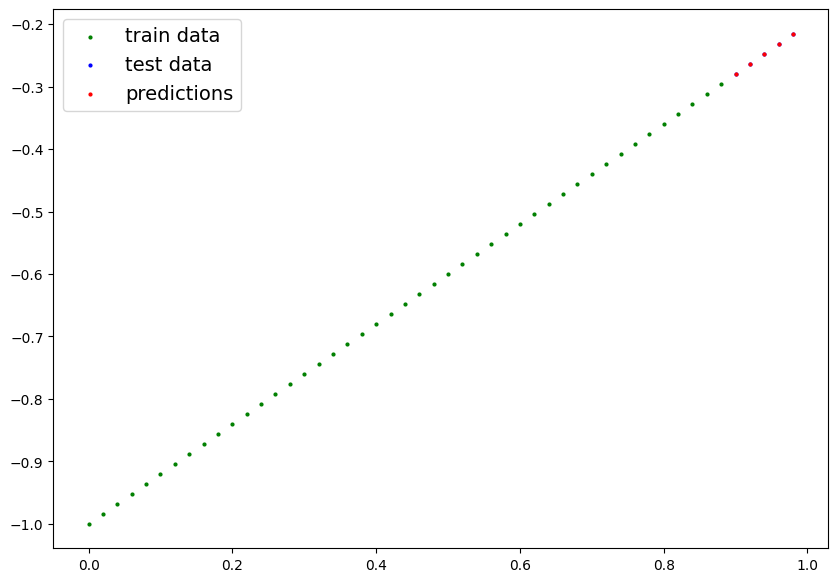

In [39]:
plot_predictions(
    train_data=X_train.cpu(),
    train_label=Y_train.cpu(),
    test_data=X_test.cpu(),
    test_label=Y_test.cpu(),
    predictions=y_preds.detach().cpu()
)

In [40]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_1.pth


In [41]:
# Instantiate a fresh instance of LinearRegressionModelV2
loaded_model_1 = Linear_Regression()

# Load model state dict
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Put model to target device (if your data is on GPU, model will have to be on GPU to make predictions)
loaded_model_1.to(device)

print(f"Loaded model:\n{loaded_model_1}")
print(f"Model on device:\n{next(loaded_model_1.parameters()).device}")

Loaded model:
Linear_Regression(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)
Model on device:
cuda:0


In [42]:
# Evaluate loaded model
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)
y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')

In [43]:
from google.colab import files
files.download("models/01_pytorch_workflow_model_1.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>